## 1. Load the Dataset
### Explanation:

- The Wine Quality dataset is loaded from OpenML.
- Features and target labels are combined and saved as wine_quality.csv.

In [3]:
from sklearn.datasets import fetch_openml
import pandas as pd

# Fetch the Wine Quality dataset
data = fetch_openml(name='wine-quality-red', as_frame=True)

# Combine features and target
df = pd.concat([data.data, data.target.rename('quality')], axis=1)

# Save dataset to CSV
df.to_csv("wine_quality.csv", index=False)
print("Dataset saved as 'wine_quality.csv'")


Dataset saved as 'wine_quality.csv'


## 2. Preprocess the Data
### Steps:
- Load the dataset.
- Scale numerical features using StandardScaler.


In [6]:
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv("wine_quality.csv")

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=['quality']))


## 3. Apply KMeans Clustering
### Steps:
- Set the number of clusters to 3.
- Apply the KMeans algorithm to cluster the data.

In [8]:
from sklearn.cluster import KMeans

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)


## 4. Visualize the Clusters
### Steps:
- Select two features for visualization.
- Plot the clusters using a scatter plot.


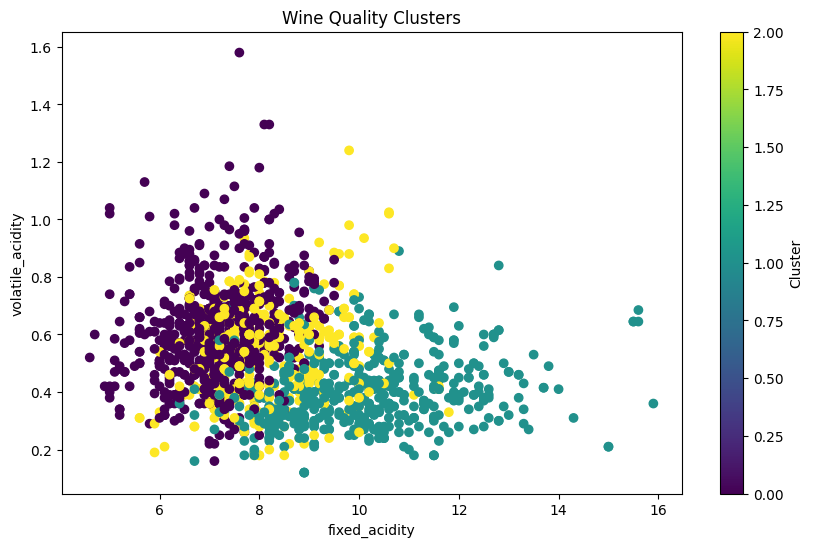

In [13]:
import matplotlib.pyplot as plt

# Choose features for visualization
feature_1 = df.columns[0]  # Replace with column name (e.g., 'alcohol')
feature_2 = df.columns[1]  # Replace with column name (e.g., 'acidity')

plt.figure(figsize=(10, 6))
plt.scatter(df[feature_1], df[feature_2], c=df['cluster'], cmap='viridis')
plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.title('Wine Quality Clusters')
plt.colorbar(label='Cluster')
plt.show()
